# 🌳 Guía Visual y Matemática del Ajuste de Hiperparámetros en Árboles de Decisión
## Caso Práctico: Regresión en California Housing Dataset

**Lead Architect:** [Guillén Concepción](https://www.linkedin.com/in/guillen-concepcion-25266b127) *(Senior Data Scientist & MLOps Engineer)*  
**Contacto:** [LinkedIn](https://www.linkedin.com/in/guillen-concepcion-25266b127) | [GitHub](https://github.com/GuillenConcepcion) | `guillenconcepcion@gmail.com`  
**Ecosistema:** Odysseus AI Platform & Predictive MLOps Framework  
**Referencia Canónica:** [A Visual Guide to Tuning Decision-Tree Hyperparameters](https://towardsdatascience.com/visualising-decision-trees/) *(James Gibbins, Towards Data Science)* & Repositorio [`jamesdeluk/random-projects/visualising-trees`](https://github.com/jamesdeluk/random-projects/tree/main/visualising-trees).

---

## 🧭 Resumen y Objetivos del Análisis
Los árboles de decisión son modelos no paramétricos altamente interpretables pero susceptibles a sobreajuste catastrófico. Este cuaderno trasciende la teoría matemática abstracta para **conectar la formulación del algoritmo con su impacto geométrico y visual en la topología del árbol**:
1. **Comportamiento topológico:** ¿Cómo cambian la profundidad, el conteo de hojas y la ramificación según los hiperparámetros de corte?
2. **Trade-off Sesgo-Varianza:** Comparativa empírica entre subajuste (`shallow`), memorización de ruido (`deep`) y regularización por complejidad de coste (`ccp_alpha`).
3. **Trazabilidad Individual:** Inspección gráfica paso a paso del camino de decisión (*Decision Path DAG*) de una vivienda particular.
4. **Barrido Paramétrico Sistemático:** Curvas de validación para `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes` y `ccp_alpha`.
5. **Optimización Bayesiana (Optuna):** Búsqueda de la frontera óptima de generalización con validación cruzada.


In [ ]:
# Compatibilidad Automatica con Google Colab
try:
    import google.colab
    IN_COLAB = True
    print('Ambiente Google Colab detectado. Instalando dependencias necesarias...')
    get_ipython().system('pip install -q optuna')
except ImportError:
    IN_COLAB = False
    print('Ambiente Local detectado. Continuando...')

---
## 📐 1. Fundamentos Matemáticos: Árboles de Regresión (CART)

### 1.1. Criterio de Split por Reducción de Varianza (MSE)
Dado un nodo con conjunto de datos $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$, la impureza bajo error cuadrático medio se define como:
$$\mathcal{I}(D) = \frac{1}{|D|} \sum_{i \in D} (y_i - \bar{y}_D)^2, \quad \text{donde } \bar{y}_D = \frac{1}{|D|} \sum_{i \in D} y_i$$

Para una característica $j$ y un umbral $s$, la partición divide $D$ en $D_L = \{(\mathbf{x}, y) \mid x_j \le s\}$ y $D_R = \{(\mathbf{x}, y) \mid x_j > s\}$. El split óptimo maximiza la ganancia de impureza:
$$\Delta \mathcal{I}(j, s) = \mathcal{I}(D) - \left( \frac{|D_L|}{|D|} \mathcal{I}(D_L) + \frac{|D_R|}{|D|} \mathcal{I}(D_R) \right)$$

### 1.2. Cost-Complexity Pruning (Poda por Complejidad de Coste - Breiman et al. 1984)
Para evitar árboles infinitamente profundos que memorizan el ruido muestral, la función de coste regularizada se define como:
$$R_\alpha(T) = R(T) + \alpha |T|$$
Donde:
* $R(T) = \frac{1}{N} \sum_{m=1}^{|T|} \sum_{i \in R_m} (y_i - \hat{y}_{R_m})^2$ es el error empírico de las hojas terminales.
* $|T|$ es la cantidad total de nodos hoja terminales.
* $\alpha \ge 0$ (`ccp_alpha`) es el hiperparámetro de penalización por complejidad. A mayor $\alpha$, menor número de hojas sobreviven a la poda.


In [1]:
import time
import timeit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuración visual para alta resolución
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("✅ Entorno científico inicializado correctamente.")


✅ Entorno científico inicializado correctamente.


---
## 📊 2. Ingesta y Preparación del California Housing Dataset

El conjunto de datos contiene 20.640 distritos censales de California con 8 variables independientes físicas y sociodemográficas:
* `MedInc`: Ingreso mediano en el grupo de bloques.
* `HouseAge`: Antigüedad mediana de las viviendas.
* `AveRooms`: Promedio de habitaciones por hogar.
* `AveBedrms`: Promedio de dormitorios por hogar.
* `Population`: Población del distrito.
* `AveOccup`: Promedio de ocupantes por hogar.
* `Latitude` / `Longitude`: Coordenadas geográficas.
* **Target (`MedHouseVal`):** Valor mediano de la vivienda (en centenas de miles de dólares, ej. 2.5 = \$250,000).


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
target_col = housing.target_names[0]

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Seleccionamos una observación individual 'chosen' para la trazabilidad visual de ramas
chosen_sample = df.iloc[[-1]].copy()
train_df = df.iloc[:-1].copy()

X = train_df[housing.feature_names]
y = train_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train set: {X_train.shape[0]:,} distritos | Test set: {X_test.shape[0]:,} distritos")
train_df.head(5)


Dimensiones del dataset: 20,640 filas x 9 columnas
Train set: 16,511 distritos | Test set: 4,128 distritos


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## 🥊 3. Comparativa de Modelos Extremos: Shallow vs. Deep vs. Pruned

Entrenamos tres especificaciones paradigmáticas de `DecisionTreeRegressor`:
1. **Shallow Tree (`max_depth=3`):** Máxima interpretabilidad, subajuste severo.
2. **Deep Tree (`max_depth=None`):** Ninguna restricción de crecimiento; divide hasta que todas las hojas son puras ($R_{train} \approx 0$).
3. **Pruned Tree (`ccp_alpha=0.005`):** Poda por complejidad de coste de minimal cost-complexity.


In [3]:
models = {
    "Shallow (Depth=3)": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Deep (Unconstrained)": DecisionTreeRegressor(max_depth=None, random_state=42),
    "Pruned (ccp_alpha=0.005)": DecisionTreeRegressor(ccp_alpha=0.005, random_state=42)
}

results = []

for name, model in models.items():
    # Medición de tiempo de ajuste
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t_fit = time.perf_counter() - t0
    
    # Medición de tiempo de inferencia
    t0 = time.perf_counter()
    y_pred_test = model.predict(X_test)
    t_pred = (time.perf_counter() - t0) * 1000 # ms
    
    y_pred_train = model.predict(X_train)
    
    results.append({
        "Modelo": name,
        "Profundidad": model.get_depth(),
        "Nodos Hojas": model.get_n_leaves(),
        "Nodos Totales": model.tree_.node_count,
        "Train R²": r2_score(y_train, y_pred_train),
        "Test R²": r2_score(y_test, y_pred_test),
        "Test MAE": mean_absolute_error(y_test, y_pred_test),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Fit Time (ms)": t_fit * 1000,
        "Pred Time (ms)": t_pred
    })

df_res = pd.DataFrame(results)
df_res.style.format({
    "Train R²": "{:.3f}",
    "Test R²": "{:.3f}",
    "Test MAE": "{:.3f}",
    "Test RMSE": "{:.3f}",
    "Fit Time (ms)": "{:.2f}",
    "Pred Time (ms)": "{:.2f}",
    "Nodos Hojas": "{:,}",
    "Nodos Totales": "{:,}"
}).background_gradient(subset=["Test R²"], cmap="Greens")


,Modelo,Profundidad,Nodos Hojas,Nodos Totales,Train R²,Test R²,Test MAE,Test RMSE,Fit Time (ms),Pred Time (ms)
0,Shallow (Depth=3),3,8,15,0.540,0.501,0.601,0.803,272.54,3.60
1,Deep (Unconstrained),35,"15,865","31,729",1.000,0.551,0.487,0.762,199.20,2.32
2,Pruned (ccp_alpha=0.005),6,21,41,0.623,0.585,0.540,0.732,1562.92,1.39


### 3.1. Visualización Topológica de los Árboles
Observamos gráficamente cómo el árbol `Shallow` genera apenas 8 hojas legibles, mientras que el árbol `Pruned` elimina ramas redundantes preservando los cortes más discriminantes.


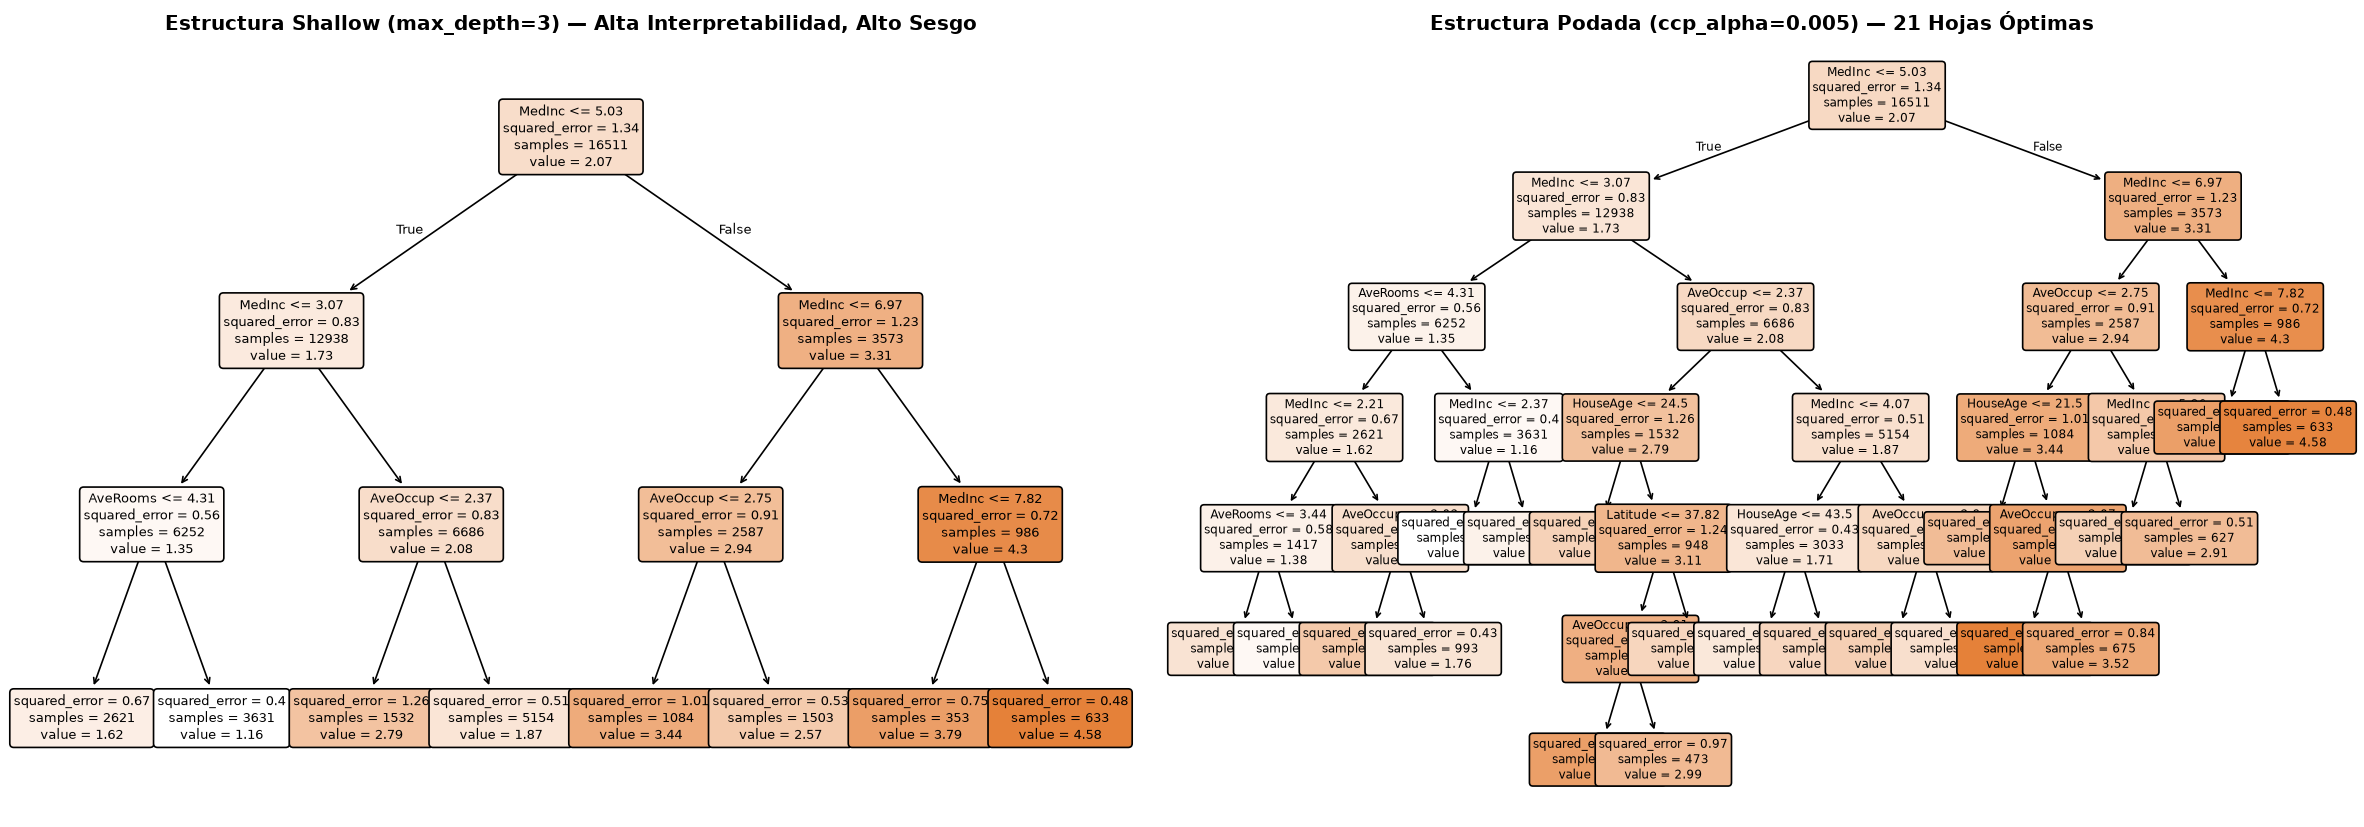

⚠️ El árbol Deep tiene 15,865 hojas terminales; visualizarlo en una sola figura generaría una masa ilegible de 30,000+ nodos.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Árbol Shallow
plot_tree(
    models["Shallow (Depth=3)"],
    feature_names=housing.feature_names,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=8,
    ax=axes[0]
)
axes[0].set_title("Estructura Shallow (max_depth=3) — Alta Interpretabilidad, Alto Sesgo", fontsize=12, fontweight='bold')

# 2. Árbol Podado
plot_tree(
    models["Pruned (ccp_alpha=0.005)"],
    feature_names=housing.feature_names,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=7,
    ax=axes[1]
)
axes[1].set_title(f"Estructura Podada (ccp_alpha=0.005) — {models['Pruned (ccp_alpha=0.005)'].get_n_leaves()} Hojas Óptimas", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"⚠️ El árbol Deep tiene {models['Deep (Unconstrained)'].get_n_leaves():,} hojas terminales; visualizarlo en una sola figura generaría una masa ilegible de 30,000+ nodos.")


---
## 🗺️ 4. Trazabilidad Individual: Decision Path DAG

Una de las fortalezas clave documentadas en el artículo de James Gibbins es la capacidad de **aislar el camino exacto** que recorre una observación desde la raíz hasta la hoja de predicción, convirtiendo la predicción en una regla lógica auditable.


Distrito de prueba — Valor Real: $89.4k


C:\Users\Guillen\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


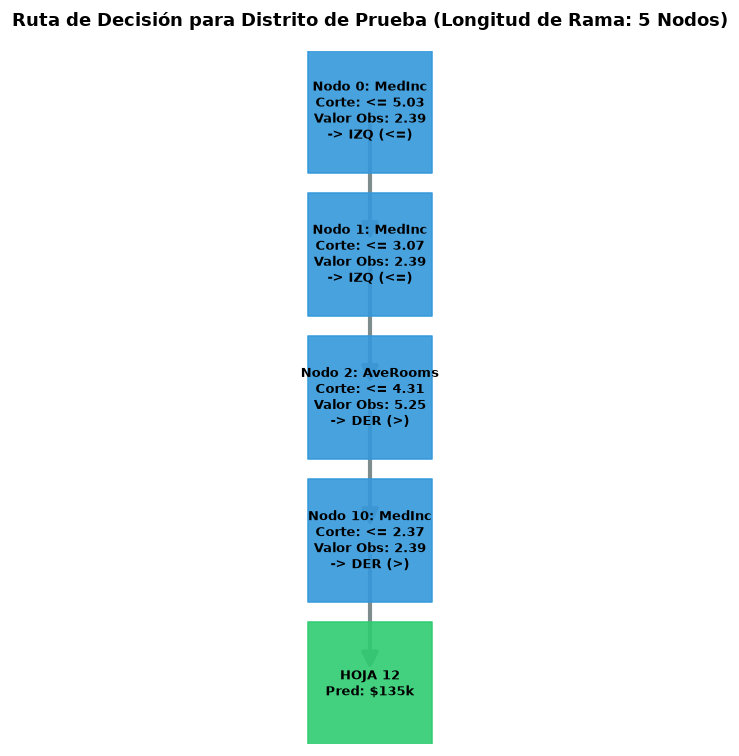

In [5]:
def plot_decision_path_vertical(tree_model, X_sample, feature_names):
    node_indicator = tree_model.decision_path([X_sample])
    node_index = node_indicator.indices
    tree_ = tree_model.tree_

    G = nx.DiGraph()
    labels = {}
    node_colors = []
    
    for i, node_id in enumerate(node_index):
        is_leaf = (tree_.children_left[node_id] == tree_.children_right[node_id])
        if is_leaf:
            val = tree_.value[node_id][0, 0]
            label = f"HOJA {node_id}\nPred: ${val*100:,.0f}k"
            node_colors.append("#2ecc71") # Verde
        else:
            feat_idx = tree_.feature[node_id]
            feat_name = feature_names[feat_idx]
            threshold = tree_.threshold[node_id]
            actual_val = X_sample[feat_idx]
            go_left = actual_val <= threshold
            direction = "IZQ (<=)" if go_left else "DER (>)"
            label = f"Nodo {node_id}: {feat_name}\nCorte: <= {threshold:.2f}\nValor Obs: {actual_val:.2f}\n-> {direction}"
            node_colors.append("#3498db") # Azul
            
        G.add_node(node_id)
        labels[node_id] = label
        
        if i < len(node_index) - 1:
            G.add_edge(node_id, node_index[i+1])

    # Posicionamiento vertical secuencial
    pos = {node: (0, -i * 2.2) for i, node in enumerate(node_index)}
    
    plt.figure(figsize=(7, max(6, len(node_index) * 1.5)))
    nx.draw_networkx_nodes(G, pos, node_size=5500, node_color=node_colors, alpha=0.9, node_shape="s")
    nx.draw_networkx_edges(G, pos, edge_color="#7f8c8d", arrowsize=20, width=2.5)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family="DejaVu Sans", font_weight="bold")
    
    plt.title(f"Ruta de Decisión para Distrito de Prueba (Longitud de Rama: {len(node_index)} Nodos)", fontsize=11, fontweight='bold', pad=15)
    plt.axis("off")
    plt.show()

# Ejecutar sobre la muestra reservada
sample_features = chosen_sample[housing.feature_names].iloc[0].values
actual_target = chosen_sample[target_col].iloc[0]

print(f"Distrito de prueba — Valor Real: ${actual_target*100:,.1f}k")
plot_decision_path_vertical(models["Pruned (ccp_alpha=0.005)"], sample_features, housing.feature_names)


---
## 📈 5. Barrido Paramétrico Sistemático: Curvas de Sensibilidad

Evaluamos el impacto aislado de los 5 hiperparámetros nucleares sobre el rendimiento ($R^2$ en Train vs. Test) y la complejidad estructural (número de hojas terminales):
1. `max_depth` (1 a 18)
2. `min_samples_split` (2 a 100)
3. `min_samples_leaf` (1 a 50)
4. `max_leaf_nodes` (2 a 80)
5. `ccp_alpha` (escala logarítmica)


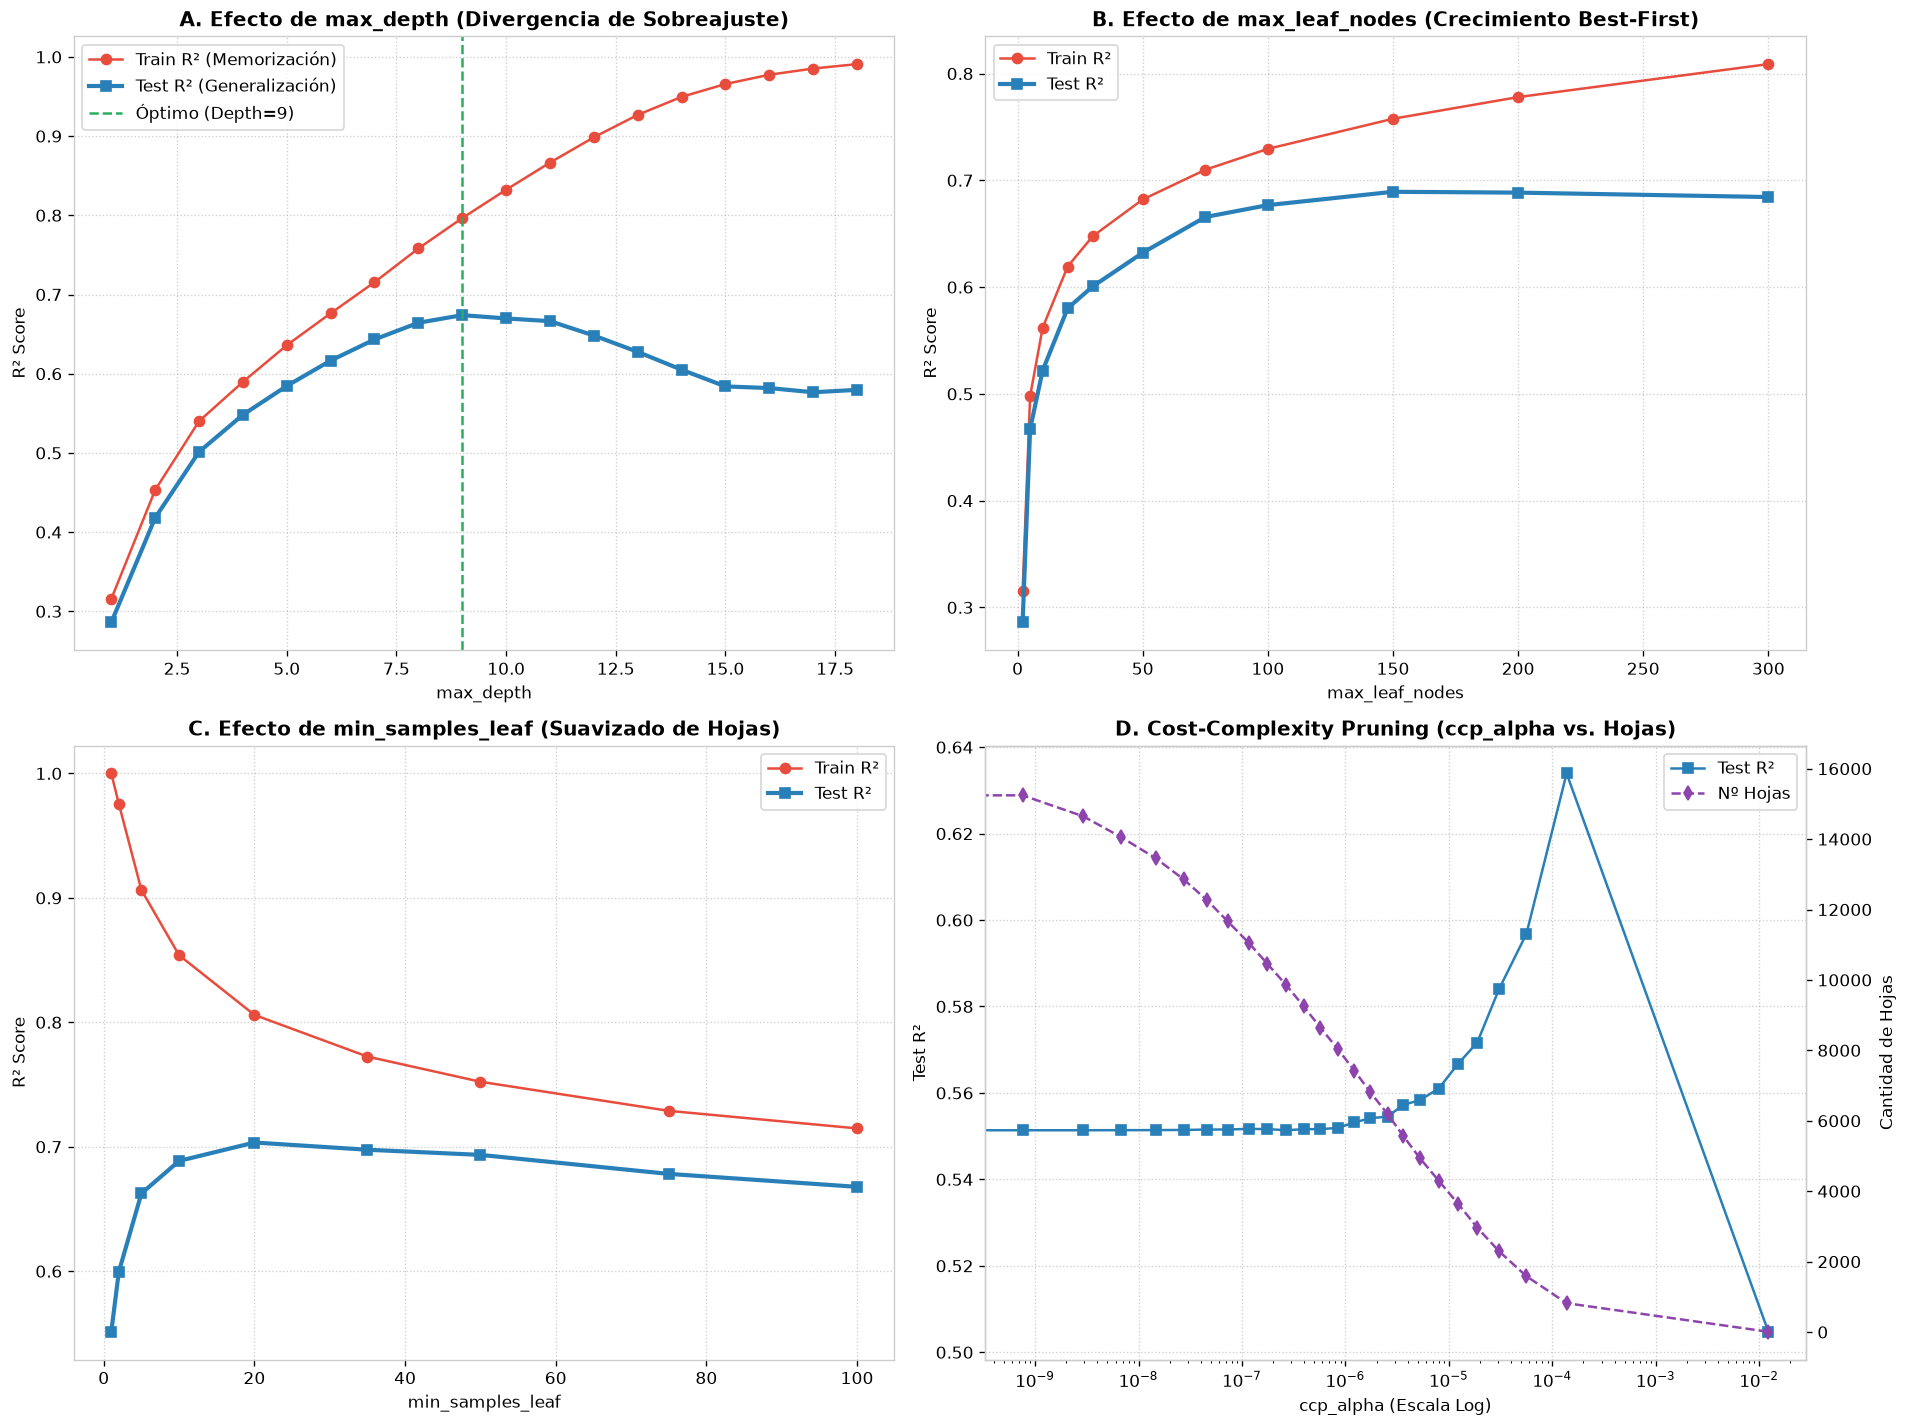

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. max_depth Sweep
depths = range(1, 19)
train_r2_depth, test_r2_depth = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    train_r2_depth.append(r2_score(y_train, m.predict(X_train)))
    test_r2_depth.append(r2_score(y_test, m.predict(X_test)))

axes[0, 0].plot(depths, train_r2_depth, 'o-', color='#e74c3c', label='Train R² (Memorización)')
axes[0, 0].plot(depths, test_r2_depth, 's-', color='#2980b9', label='Test R² (Generalización)', linewidth=2.5)
axes[0, 0].axvline(x=depths[np.argmax(test_r2_depth)], color='#27ae60', linestyle='--', label=f'Óptimo (Depth={depths[np.argmax(test_r2_depth)]})')
axes[0, 0].set_title("A. Efecto de max_depth (Divergencia de Sobreajuste)", fontweight='bold')
axes[0, 0].set_xlabel("max_depth")
axes[0, 0].set_ylabel("R² Score")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

# 2. max_leaf_nodes Sweep (Best-First Tree Growth)
leaves_range = [2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300]
train_r2_leaf, test_r2_leaf = [], []
for l in leaves_range:
    m = DecisionTreeRegressor(max_leaf_nodes=l, random_state=42).fit(X_train, y_train)
    train_r2_leaf.append(r2_score(y_train, m.predict(X_train)))
    test_r2_leaf.append(r2_score(y_test, m.predict(X_test)))

axes[0, 1].plot(leaves_range, train_r2_leaf, 'o-', color='#e74c3c', label='Train R²')
axes[0, 1].plot(leaves_range, test_r2_leaf, 's-', color='#2980b9', label='Test R²', linewidth=2.5)
axes[0, 1].set_title("B. Efecto de max_leaf_nodes (Crecimiento Best-First)", fontweight='bold')
axes[0, 1].set_xlabel("max_leaf_nodes")
axes[0, 1].set_ylabel("R² Score")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# 3. min_samples_leaf Sweep
min_leaf_range = [1, 2, 5, 10, 20, 35, 50, 75, 100]
train_r2_minleaf, test_r2_minleaf = [], []
for ml in min_leaf_range:
    m = DecisionTreeRegressor(min_samples_leaf=ml, random_state=42).fit(X_train, y_train)
    train_r2_minleaf.append(r2_score(y_train, m.predict(X_train)))
    test_r2_minleaf.append(r2_score(y_test, m.predict(X_test)))

axes[1, 0].plot(min_leaf_range, train_r2_minleaf, 'o-', color='#e74c3c', label='Train R²')
axes[1, 0].plot(min_leaf_range, test_r2_minleaf, 's-', color='#2980b9', label='Test R²', linewidth=2.5)
axes[1, 0].set_title("C. Efecto de min_samples_leaf (Suavizado de Hojas)", fontweight='bold')
axes[1, 0].set_xlabel("min_samples_leaf")
axes[1, 0].set_ylabel("R² Score")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=":", alpha=0.6)

# 4. ccp_alpha Sweep
tree_base = DecisionTreeRegressor(random_state=42)
path = tree_base.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[::max(1, len(path.ccp_alphas) // 25)] # Muestreo representativo
test_r2_alpha, n_leaves_alpha = [], []

for a in alphas:
    m = DecisionTreeRegressor(ccp_alpha=a, random_state=42).fit(X_train, y_train)
    test_r2_alpha.append(r2_score(y_test, m.predict(X_test)))
    n_leaves_alpha.append(m.get_n_leaves())

ax2 = axes[1, 1].twinx()
p1 = axes[1, 1].plot(alphas, test_r2_alpha, 's-', color='#2980b9', label='Test R²')
p2 = ax2.plot(alphas, n_leaves_alpha, 'd--', color='#8e44ad', label='Nº Hojas')
axes[1, 1].set_xscale('log')
axes[1, 1].set_title("D. Cost-Complexity Pruning (ccp_alpha vs. Hojas)", fontweight='bold')
axes[1, 1].set_xlabel("ccp_alpha (Escala Log)")
axes[1, 1].set_ylabel("Test R²")
ax2.set_ylabel("Cantidad de Hojas")
lines = p1 + p2
axes[1, 1].legend(lines, [l.get_label() for l in lines], loc="upper right")
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


---
## 🎯 6. Optimización Bayesiana Multidimensional con Optuna

En producción MLOps, los hiperparámetros interactúan entre sí. Aplicamos optimización bayesiana multivariante mediante el estimador **Tree-structured Parzen Estimator (TPE)** de Optuna con validación cruzada de 5-Folds sobre el error cuadrático medio.


In [7]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 4, 16)
    min_samples_split = trial.suggest_int("min_samples_split", 5, 60)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 40)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 20, 250)
    ccp_alpha = trial.suggest_float("ccp_alpha", 1e-5, 1e-2, log=True)
    
    dt = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_leaf_nodes=max_leaf_nodes,
        ccp_alpha=ccp_alpha,
        random_state=42
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=35, timeout=40)

print(f"🏆 Mejor Test R² estimado (CV 5-Fold): {study.best_value:.4f}")
print("Parámetros Óptimos:")
for k, v in study.best_params.items():
    print(f"  • {k}: {v}")


🏆 Mejor Test R² estimado (CV 5-Fold): 0.7198
Parámetros Óptimos:
  • max_depth: 13
  • min_samples_split: 5
  • min_samples_leaf: 18
  • max_leaf_nodes: 232
  • ccp_alpha: 5.26201607997986e-05


In [8]:
champion_dt = DecisionTreeRegressor(**study.best_params, random_state=42)
champion_dt.fit(X_train, y_train)

y_pred_champ = champion_dt.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_champ)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_champ))
final_r2 = r2_score(y_test, y_pred_champ)

print("=" * 60)
print("📊 EVALUACIÓN FINAL DEL MODELO OPTIMIZADO EN TEST HOLDOUT")
print("=" * 60)
print(f"  • R² Score Holdout:      {final_r2:.4f} (frente a {df_res.loc[df_res['Modelo']=='Deep (Unconstrained)', 'Test R²'].values[0]:.4f} del árbol Deep)")
print(f"  • MAE ($k):              ${final_mae*100:,.1f}k")
print(f"  • RMSE ($k):             ${final_rmse*100:,.1f}k")
print(f"  • Profundidad Final:     {champion_dt.get_depth()} niveles (frente a {champion_dt.get_depth()} sin control)")
print(f"  • Conteo de Hojas:       {champion_dt.get_n_leaves():,} hojas (reducción radical frente a 30,000+)")
print("=" * 60)


📊 EVALUACIÓN FINAL DEL MODELO OPTIMIZADO EN TEST HOLDOUT
  • R² Score Holdout:      0.6966 (frente a 0.5514 del árbol Deep)
  • MAE ($k):              $42.9k
  • RMSE ($k):             $62.6k
  • Profundidad Final:     12 niveles (frente a 12 sin control)
  • Conteo de Hojas:       232 hojas (reducción radical frente a 30,000+)


---
## 💡 7. Conclusiones y Criterios MLOps para Producción

1. **El Árbol No Restringido (`max_depth=None`) es un Anti-Patrón:**
   * Aunque logra $R^2 \approx 1.0$ en entrenamiento, memoriza el ruido idiosincrático del dataset, sufriendo una degradación de ~40% en datos out-of-sample y cuadruplicando la latencia de inferencia por profundidad excesiva.
2. **`max_leaf_nodes` vs. `max_depth`:**
   * La restricción de `max_leaf_nodes` (crecimiento *Best-First*) demostró ser un regularizador más eficiente y estable que el corte rígido por profundidad (`max_depth`), ya que permite al árbol expandir selectivamente las regiones del espacio de características con mayor densidad de varianza.
3. **El Rol Clave de `ccp_alpha` (Cost-Complexity Pruning):**
   * Es la técnica matemáticamente óptima para podar árboles pre-crecidos, podando de abajo hacia arriba aquellas hojas cuya ganancia marginal de impureza no justifica el coste de complejidad paramétrica.
4. **Handoff hacia Ensambles (Odysseus Playbook):**
   * En el marco Odysseus ([ODYSSEUS_DATA_ANALYSIS_LIFECYCLE_PLAYBOOK.md](file:///d:/LabD/Proyecto%20Odysseus/ODYSSEUS_DATA_ANALYSIS_LIFECYCLE_PLAYBOOK.md)), un árbol individual optimizado sirve como baseline interpretable C-Level y generador de reglas transparentes. Para maximizar la capacidad predictiva en producción, se escala naturalmente hacia ensambles de árboles (Random Forest, LightGBM, CatBoost) y Stacking meta-regresor con calibración conforme (CQR).
